In [ ]:
import marimo as mo

# Delta-Minimax Group Sequential Design via Constrained Bayesian Optimisation
## Reverse Parameterisation + Integer $n$ by Bisection + Failure Region ($\alpha'$ only)

This notebook combines three ideas:

1. **Reverse parameterisation** — structural constraints (monotonicity, meeting
point) are satisfied automatically by construction. Every proposed design is
structurally valid.

2. **Integer $n$ by bisection** — rather than including $n$ as a BO parameter,
for each proposed boundary set the smallest integer $n$ achieving the required
power $1 - \beta^*$ is found by bisection. This guarantees $\beta' \leq \beta^*$
by construction, reducing the BO to 5 parameters and leaving only the $\alpha'$
constraint to be learned.

3. **Constrained BO with failure region** — the $\alpha'$ constraint is handled
by a VGP classifier. The acquisition function is $\text{EI} \times \text{PoV}$,
where PoV is the probability that $\alpha' \leq \alpha^*$. The GPR is trained
only on feasible designs (those where both constraints are satisfied).

# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
import gpflow
from gpflow.keras import tf_keras
import trieste
from trieste.space import Box
from trieste.models.gpflow.models import (
    GaussianProcessRegression,
    VariationalGaussianProcess,
)
from trieste.models import TrainableProbabilisticModel
from trieste.models.optimizer import BatchOptimizer
from trieste.types import Tag
from trieste.acquisition.rule import EfficientGlobalOptimization
from trieste.acquisition import (
    SingleModelAcquisitionBuilder,
    ExpectedImprovement,
    Product,
)

/opt/venv/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
from py_group_sequential_designs import feasibility_penalty as fp
from py_group_sequential_designs import function_to_minimize as fn_min
from py_group_sequential_designs import generate_boundaries as bd
from py_group_sequential_designs import simulate as sim
from py_group_sequential_designs import sample_size as ss

# Trial Design Settings

In [ ]:
num_analyses  = 3
target_alpha  = 0.05
target_power  = 0.9
delta1        = 1.0
sigma2        = 3.0

mu = ss.sample_size_means(
    ratio=1, variance=sigma2, power=target_power,
    alpha=target_alpha, delta=delta1
)
print(f"Single-stage sample size mu = {mu:.2f}")

Single-stage sample size mu = 154.15


# Reverse Parameterisation

The BO parameter vector is now 5-dimensional:
$$\tilde{\theta} = (c,\, \Delta u_K, \Delta l_K, \ldots, \Delta u_2, \Delta l_2)$$

$n$ is **not** a BO parameter — it is determined by integer bisection for each
proposed boundary set.

In [ ]:
def reverse_to_boundaries(params, K):
    """
    Convert 5-dim reverse-param vector (no n) to (upper_bounds, lower_bounds).
    params = [c, delta_u_K, delta_l_K, ..., delta_u_2, delta_l_2]
    """
    params  = np.asarray(params).flatten()
    c       = params[0]
    delta_u = params[1::2][::-1]   # delta_u_2, ..., delta_u_K
    delta_l = params[2::2][::-1]   # delta_l_2, ..., delta_l_K

    upper_bounds = np.array([c + np.sum(delta_u[k:]) for k in range(K)])
    lower_bounds = np.array([c - np.sum(delta_l[k:]) for k in range(K)])
    return upper_bounds, lower_bounds


def boundaries_to_reverse(upper_bounds, lower_bounds):
    """
    Convert (upper_bounds, lower_bounds) to 5-dim reverse-param vector (no n).
    """
    upper_bounds = np.asarray(upper_bounds)
    lower_bounds = np.asarray(lower_bounds)
    K       = len(upper_bounds)
    c       = upper_bounds[-1]
    delta_u = np.diff(upper_bounds[::-1])
    delta_l = np.diff(lower_bounds)[::-1]
    increments       = np.empty(2 * (K - 1))
    increments[0::2] = delta_u
    increments[1::2] = delta_l
    return np.concatenate([[c], increments])

In [ ]:
# sanity check
_upper = np.array([2.12, 1.87, 1.84])
_lower = np.array([0.0,  1.12, 1.84])
_params = boundaries_to_reverse(_upper, _lower)
_u2, _l2 = reverse_to_boundaries(_params, K=3)
print("Original upper:", _upper)
print("Recovered upper:", np.round(_u2, 6))
print("Original lower:", _lower)
print("Recovered lower:", np.round(_l2, 6))
print("Params:", np.round(_params, 6))

Original upper: [2.12 1.87 1.84]
Recovered upper: [2.12 1.87 1.84]
Original lower: [0.   1.12 1.84]
Recovered lower: [0.   1.12 1.84]
Params: [1.84 0.03 0.72 0.25 1.12]


# Integer $n$ by Bisection

For a given boundary set, find the smallest integer $n$ per arm per stage
such that power $\geq 1 - \beta^*$. Returns `None` if no $n \leq n_{\max}$
achieves the required power — the design is then infeasible regardless of $n$.

In [ ]:
def find_n_integer(upper_bounds, lower_bounds, target_power,
                   n_min=2, n_max=200):
    """
    Find smallest integer n per arm per stage achieving target power,
    using bisection over integers.

    Returns n (int) if achievable within [n_min, n_max], else None.
    """
    # check n_max is sufficient
    _, _, power_max, _ = sim.group_sequential_designs(
        n_analyses   = num_analyses,
        upper_bounds = upper_bounds,
        lower_bounds = lower_bounds,
        n_patients   = n_max,
        null_hypothesis = 0,
        alt_hypothesis  = delta1,
        variance        = sigma2
    )
    if power_max < target_power:
        return None   # boundaries too poor — no feasible n

    # bisect over integers
    while n_max - n_min > 1:
        n_mid = (n_min + n_max) // 2
        _, _, power_mid, _ = sim.group_sequential_designs(
            n_analyses   = num_analyses,
            upper_bounds = upper_bounds,
            lower_bounds = lower_bounds,
            n_patients   = n_mid,
            null_hypothesis = 0,
            alt_hypothesis  = delta1,
            variance        = sigma2
        )
        if power_mid >= target_power:
            n_max = n_mid
        else:
            n_min = n_mid

    return int(n_max)   # smallest integer n achieving target power

# Objective Function

For each proposed boundary set $\tilde{\theta} = (c, \Delta u_K, \Delta l_K, \ldots)$:

1. Convert to $(u_k, l_k)$ via reverse parameterisation
2. Find integer $n$ by bisection — if none exists, design is infeasible
3. Compute $\alpha'$ — if $\alpha' > \alpha^*$, design is infeasible
4. If feasible, compute $\max_\delta E[N \mid \delta] / \mu$ as objective

Returns $(x, y_{\text{obj}}, \text{feasible})$.
$\beta' \leq \beta^*$ is **guaranteed by construction** via step 2.
Only $\alpha'$ needs the VGP.

In [ ]:
def objective(params, mu, target_power, target_alpha, K):
    params = np.asarray(params).flatten()
    upper_bounds, lower_bounds = reverse_to_boundaries(params, K)

    # step 1: find integer n achieving target power
    n = find_n_integer(
        upper_bounds = upper_bounds,
        lower_bounds = lower_bounds,
        target_power = target_power
    )

    if n is None:
        # no feasible n exists for these boundaries
        return (
            np.array([params]),
            np.array([[np.nan]]),
            np.array([[0.0]])
        )

    # step 2: evaluate alpha' at this n
    trial = sim.group_sequential_designs(
        n_analyses      = K,
        upper_bounds    = upper_bounds,
        lower_bounds    = lower_bounds,
        n_patients      = n,
        null_hypothesis = 0,
        alt_hypothesis  = delta1,
        variance        = sigma2
    )
    alpha_prime = trial[1]

    # step 3: feasibility — only alpha' needs checking
    # (beta' guaranteed by bisection)
    feasible = int(alpha_prime <= target_alpha)

    if not feasible:
        return (
            np.array([params]),
            np.array([[np.nan]]),
            np.array([[0.0]])
        )

    # step 4: compute objective
    max_ess = ss.max_ess(
        n_analyses      = K,
        upper_bounds    = upper_bounds,
        lower_bounds    = lower_bounds,
        n_patients      = n,
        null_hypothesis = 0,
        variance        = sigma2
    )

    y_obj = max_ess / mu   # no penalty needed: both constraints satisfied

    return (
        np.array([params]),
        np.array([[y_obj]]),
        np.array([[1.0]])
    )

In [ ]:
_tri = bd.calculate_triangular_boundaries(
    n_analyses=num_analyses, alpha=target_alpha, delta=delta1, n_patients=20
)
tri_params = boundaries_to_reverse(_tri[0], _tri[1])
c0         = tri_params[0]   # first element is c in 5-dim vector

_, _y, _feas = objective(tri_params, mu, target_power, target_alpha, num_analyses)
print(f"Triangular benchmark — objective: {_y[0,0]:.4f}, feasible: {bool(_feas[0,0])}")
print(f"Triangular params (5-dim): {np.round(tri_params, 4)}")
print(f"Meeting point c0 = {c0:.4f}")

Triangular benchmark — objective: nan, feasible: False
Triangular params (5-dim): [1.8356 0.0379 0.7115 0.2461 1.1241]
Meeting point c0 = 1.8356


# Search Space

5-dimensional: $(c, \Delta u_3, \Delta l_3, \Delta u_2, \Delta l_2)$.
$n$ is no longer a BO parameter.

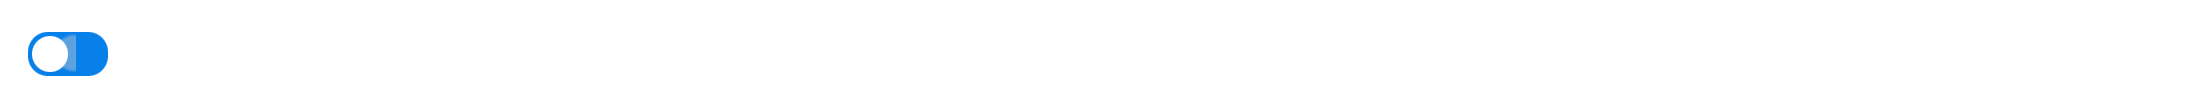

In [ ]:
use_local_search = mo.ui.switch(value=True, label="Use local search space")
use_local_search

In [ ]:
_hw_c     = 0.3
_hw_delta = 0.3

if use_local_search.value:
    _lower = np.array([
        c0 - _hw_c,
        max(0.0, tri_params[1] - _hw_delta),
        max(0.0, tri_params[2] - _hw_delta),
        max(0.0, tri_params[3] - _hw_delta),
        max(0.0, tri_params[4] - _hw_delta),
    ])
    _upper = np.array([
        c0 + _hw_c,
        tri_params[1] + _hw_delta,
        tri_params[2] + _hw_delta,
        tri_params[3] + _hw_delta,
        tri_params[4] + _hw_delta,
    ])
    _label = "LOCAL"
else:
    _lower = np.array([c0 - 3.0, 0.0, 0.0, 0.0, 0.0])
    _upper = np.array([c0 + 3.0, 4.0, 4.0, 4.0, 4.0])
    _label = "GLOBAL"

search_space = Box(lower=_lower, upper=_upper)

print(f"Search space ({_label}):")
print(f"  lower: {np.round(search_space.lower.numpy(), 3)}")
print(f"  upper: {np.round(search_space.upper.numpy(), 3)}")
print(f"\nTriangular params for reference: {np.round(tri_params, 4)}")

Search space (LOCAL):
  lower: [1.536 0.    0.412 0.    0.824]
  upper: [2.136 0.338 1.012 0.546 1.424]

Triangular params for reference: [1.8356 0.0379 0.7115 0.2461 1.1241]


# Initialisation

- **Perturbations** around Pocock, O'Brien-Fleming, and triangular designs
- **Random feasible points** from pool sampled within search space

All points guaranteed to have $\beta' \leq \beta^*$ (via bisection).
Only $\alpha'$ determines feasibility label.

In [ ]:
rng_init = np.random.default_rng(seed=42)

# reference designs in 5-dim reverse parameterisation
_poc = bd.calculate_pocock_boundaries(
    n_analyses=num_analyses, alpha=target_alpha, n_patients=20
)
poc_params = boundaries_to_reverse(_poc[0], _poc[1])

_obf = bd.calculate_of_boundaries(
    n_analyses=num_analyses, alpha=target_alpha, n_patients=20
)
obf_params = boundaries_to_reverse(_obf[0], _obf[1])

# part 1: perturbations around known designs
# in local search, only perturb around triangular (assumed near-optimal)
# in global search, also include Pocock and O'Brien-Fleming for coverage
_refs_to_perturb = [tri_params] if use_local_search.value else [poc_params, obf_params, tri_params]
_n_perturb       = 15 if use_local_search.value else 5   # more perturbations in local case

all_x, all_y_obj, all_feas = [], [], []
for _ref in _refs_to_perturb:
    for _ in range(_n_perturb):
        _scale = np.clip(np.abs(_ref) * 0.10, 0.01, 0.3)
        _p     = _ref + rng_init.normal(scale=_scale, size=len(_ref))
        _p[1:] = np.clip(_p[1:], 0.0, 4.0)
        _x, _y, _f = objective(_p, mu, target_power, target_alpha, num_analyses)
        all_x.append(_x); all_y_obj.append(_y); all_feas.append(_f)

n_feas_perturb = sum(int(_f[0,0]) for _f in all_feas)
print(f"Perturbation points: {len(all_x)} total, {n_feas_perturb} feasible")

# part 2: random feasible points from pool within search space
n_target = 15
n_found  = 0
n_tried  = 0
_lb = search_space.lower.numpy()
_ub = search_space.upper.numpy()
_candidates = rng_init.uniform(_lb, _ub, size=(1000, len(_lb)))

for _p in _candidates:
    _x, _y, _f = objective(_p, mu, target_power, target_alpha, num_analyses)
    all_x.append(_x); all_y_obj.append(_y); all_feas.append(_f)
    n_tried += 1
    if int(_f[0, 0]) == 1:
        n_found += 1
    if n_found >= n_target:
        break

print(f"Random feasible points: {n_found} found from {n_tried} candidates")
print(f"Total initial points: {len(all_x)}")

Perturbation points: 15 total, 8 feasible
Random feasible points: 15 found from 26 candidates
Total initial points: 41


In [ ]:
_all_x_arr    = np.concatenate(all_x)
_all_feas_arr = np.concatenate(all_feas)
_feas_mask    = _all_feas_arr.flatten() == 1

_obj_x = _all_x_arr[_feas_mask]
_obj_y = np.concatenate(all_y_obj)[_feas_mask]

initial_data = {
    "objective": trieste.data.Dataset(
        query_points = _obj_x,
        observations = _obj_y
    ),
    "failure": trieste.data.Dataset(
        query_points = _all_x_arr,
        observations = _all_feas_arr
    )
}

print(f"Objective dataset: {_obj_x.shape[0]} feasible points")
print(f"Failure dataset:   {_all_x_arr.shape[0]} total points")
print(f"Objective values:  {[round(float(v), 4) for v in _obj_y.flatten()]}")

Objective dataset: 23 feasible points
Failure dataset:   41 total points
Objective values:  [0.2872, 0.3099, 0.3668, 0.3272, 0.3022, 0.2829, 0.2933, 0.3144, 0.3217, 0.323, 0.2903, 0.2904, 0.3146, 0.2908, 0.3162, 0.3473, 0.3196, 0.3107, 0.3187, 0.3706, 0.2866, 0.3418, 0.2825]


# Models

- **GPR** (Matern52, ARD) on feasible designs only — learns objective landscape
- **VGP** (Squared Exponential, Bernoulli) on all designs — learns $\alpha'$ feasibility

In [ ]:
_n_dims = initial_data["objective"].query_points.shape[1]

_gpr_kernel = gpflow.kernels.Matern52(lengthscales=[1.0] * _n_dims)
_gpr = gpflow.models.GPR(
    data=(
        initial_data["objective"].query_points,
        initial_data["objective"].observations
    ),
    kernel=_gpr_kernel,
    likelihood=gpflow.likelihoods.Gaussian()
)

_vgp_kernel = gpflow.kernels.SquaredExponential(lengthscales=[1.0] * _n_dims)
_vgp = gpflow.models.VGP(
    data=(
        initial_data["failure"].query_points,
        initial_data["failure"].observations
    ),
    kernel=_vgp_kernel,
    likelihood=gpflow.likelihoods.Bernoulli()
)

models: dict[Tag, TrainableProbabilisticModel] = {
    "objective": GaussianProcessRegression(_gpr),
    "failure":   VariationalGaussianProcess(
        _vgp,
        optimizer=BatchOptimizer(tf_keras.optimizers.Adam(learning_rate=1e-3)),
        use_natgrads=True
    )
}

In [ ]:
class ProbabilityOfValidity(SingleModelAcquisitionBuilder):
    def prepare_acquisition_function(self, model, dataset=None):
        def acquisition(at):
            mean, _ = model.predict_y(tf.squeeze(at, -2))
            return mean
        return acquisition

ei     = ExpectedImprovement()
pov    = ProbabilityOfValidity()
acq_fn = Product(ei.using("objective"), pov.using("failure"))

rule = EfficientGlobalOptimization(
    acq_fn,
    optimizer=trieste.acquisition.optimizer.generate_continuous_optimizer(
        num_optimization_runs=500
    )
)

In [ ]:
ask_tell = trieste.ask_tell_optimization.AskTellOptimizer(
    search_space     = search_space,
    datasets         = initial_data,
    models           = models,
    acquisition_rule = rule
)

# Bayesian Optimisation Loop

At each iteration:
1. **Ask** — propose boundary set $(c, \Delta u_3, \Delta l_3, \Delta u_2, \Delta l_2)$
2. **Bisect** — find integer $n$ achieving $\beta' \leq \beta^*$
3. **Check** $\alpha'$ — determines feasibility label
4. **Tell** — update failure dataset always; objective dataset only if feasible

In [ ]:
num_repeats   = 500
when_to_print = 50
n_feasible_bo = 0

for _i in range(num_repeats):
    x_new = ask_tell.ask()

    _x, _y_obj, _feas = objective(
        params       = x_new,
        mu           = mu,
        target_power = target_power,
        target_alpha = target_alpha,
        K            = num_analyses
    )

    _is_feasible = int(_feas[0, 0]) == 1
    if _is_feasible:
        n_feasible_bo += 1

    new_data = {
        "failure": trieste.data.Dataset(
            query_points = _x,
            observations = _feas
        )
    }

    if _is_feasible:
        new_data["objective"] = trieste.data.Dataset(
            query_points = _x,
            observations = _y_obj
        )
    else:
        new_data["objective"] = trieste.data.Dataset(
            query_points = np.reshape(np.array([]), (0, _x.shape[1])),
            observations = np.reshape(np.array([]), (0, 1))
        )

    ask_tell.tell(new_data=new_data)

    if (_i + 1) % when_to_print == 0:
        print(f"\nLoop {_i+1} completed. "
              f"Feasible so far: {n_feasible_bo}/{_i+1}", end="")
    elif (_i > when_to_print) and ((_i + 1) % 5 == 0):
        print(".", end="")

print(f"\nDone. Feasible BO proposals: {n_feasible_bo}/{num_repeats}")


Loop 50 completed. Feasible so far: 5/50.........
Loop 100 completed. Feasible so far: 10/100.........
Loop 150 completed. Feasible so far: 15/150.........
Loop 200 completed. Feasible so far: 22/200..

2026-04-03 19:39:59.899360: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-04-03 19:39:59.913862: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: gpflow.Parameter: the value to be assigned is incompatible with this parameter's transform (the corresponding unconstrained value has NaN or Inf) and hence cannot be assigned. : Tensor had NaN values


InvalidArgumentError: {{function_node __wrapped__CheckNumerics_device_/job:localhost/replica:0/task:0/device:CPU:0}} gpflow.Parameter: the value to be assigned is incompatible with this parameter's transform (the corresponding unconstrained value has NaN or Inf) and hence cannot be assigned. : Tensor had NaN values [Op:CheckNumerics] name

# Results

In [ ]:
final_obj_dataset = ask_tell.to_result().try_get_final_datasets()["objective"]

best_idx    = int(np.argmin(final_obj_dataset.observations.numpy()))
best_params = final_obj_dataset.query_points.numpy()[best_idx]
best_obj    = float(final_obj_dataset.observations.numpy()[best_idx])

best_upper, best_lower = reverse_to_boundaries(best_params, num_analyses)
best_n = find_n_integer(best_upper, best_lower, target_power)

print(f"Best objective value: {best_obj:.4f}")
print(f"n per arm per stage:  {best_n}")
print(f"Upper boundaries:     {np.round(best_upper, 4)}")
print(f"Lower boundaries:     {np.round(best_lower, 4)}")

/tmp/marimo_2778/__marimo__cell_pHFh_.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  best_obj    = float(final_obj_dataset.observations.numpy()[best_idx])


Best objective value: 0.2763
n per arm per stage:  22
Upper boundaries:     [2.0704 1.893  1.893 ]
Lower boundaries:     [-6.0000e-04  1.1781e+00  1.8930e+00]


In [ ]:
_trial = sim.group_sequential_designs(
    n_analyses=num_analyses, upper_bounds=best_upper, lower_bounds=best_lower,
    n_patients=best_n, null_hypothesis=0, alt_hypothesis=delta1, variance=sigma2
)
print(f"Achieved alpha':  {_trial[1]:.4f}  (target <= {target_alpha})")
print(f"Achieved power':  {_trial[2]:.4f}  (target >= {target_power})")
print()
print("Triangular benchmark:")
print(f"  Upper: [2.1196, 1.8735, 1.8356]")
print(f"  Lower: [0.0000, 1.1241, 1.8356]")
print(f"  n: 22,  objective: 0.2715")

Achieved alpha':  0.0497  (target <= 0.05)
Achieved power':  0.9012  (target >= 0.9)

Triangular benchmark:
  Upper: [2.1196, 1.8735, 1.8356]
  Lower: [0.0000, 1.1241, 1.8356]
  n: 22,  objective: 0.2715


## Objective function history (feasible designs only)

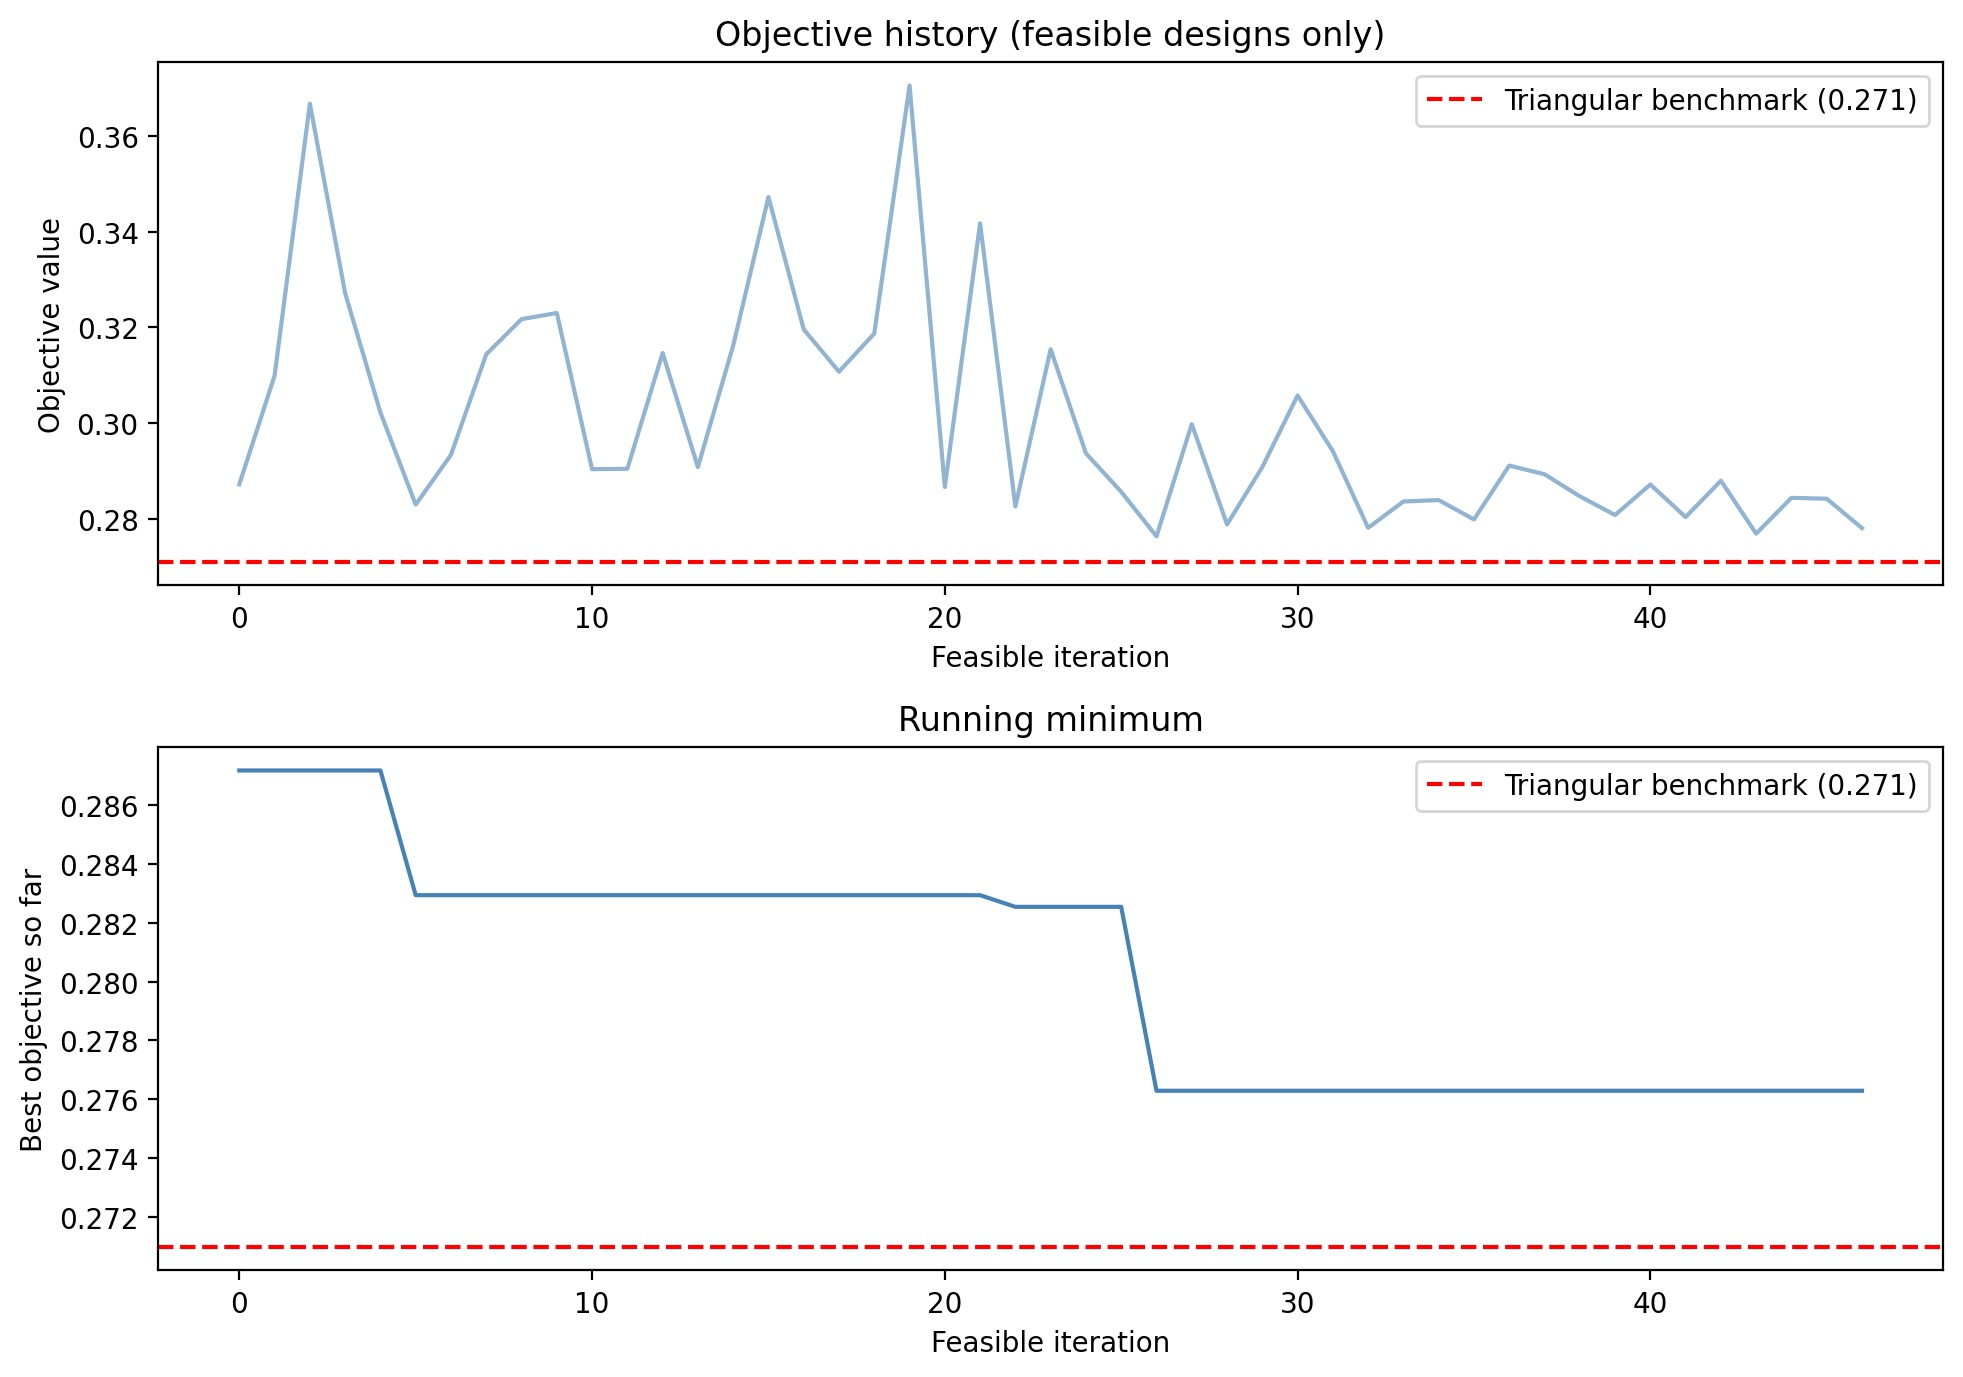

In [ ]:
_obs         = final_obj_dataset.observations.numpy().flatten()
_running_min = np.minimum.accumulate(_obs)

_fig, _axes = plt.subplots(nrows=2, figsize=(10, 7))

_axes[0].plot(_obs, alpha=0.6, color="steelblue")
_axes[0].axhline(y=0.271, color="red", linestyle="--",
                 label="Triangular benchmark (0.271)")
_axes[0].set_xlabel("Feasible iteration")
_axes[0].set_ylabel("Objective value")
_axes[0].set_title("Objective history (feasible designs only)")
_axes[0].legend()

_axes[1].plot(_running_min, color="steelblue")
_axes[1].axhline(y=0.271, color="red", linestyle="--",
                 label="Triangular benchmark (0.271)")
_axes[1].set_xlabel("Feasible iteration")
_axes[1].set_ylabel("Best objective so far")
_axes[1].set_title("Running minimum")
_axes[1].legend()

_fig.tight_layout()
_fig

## Best design vs triangular benchmark

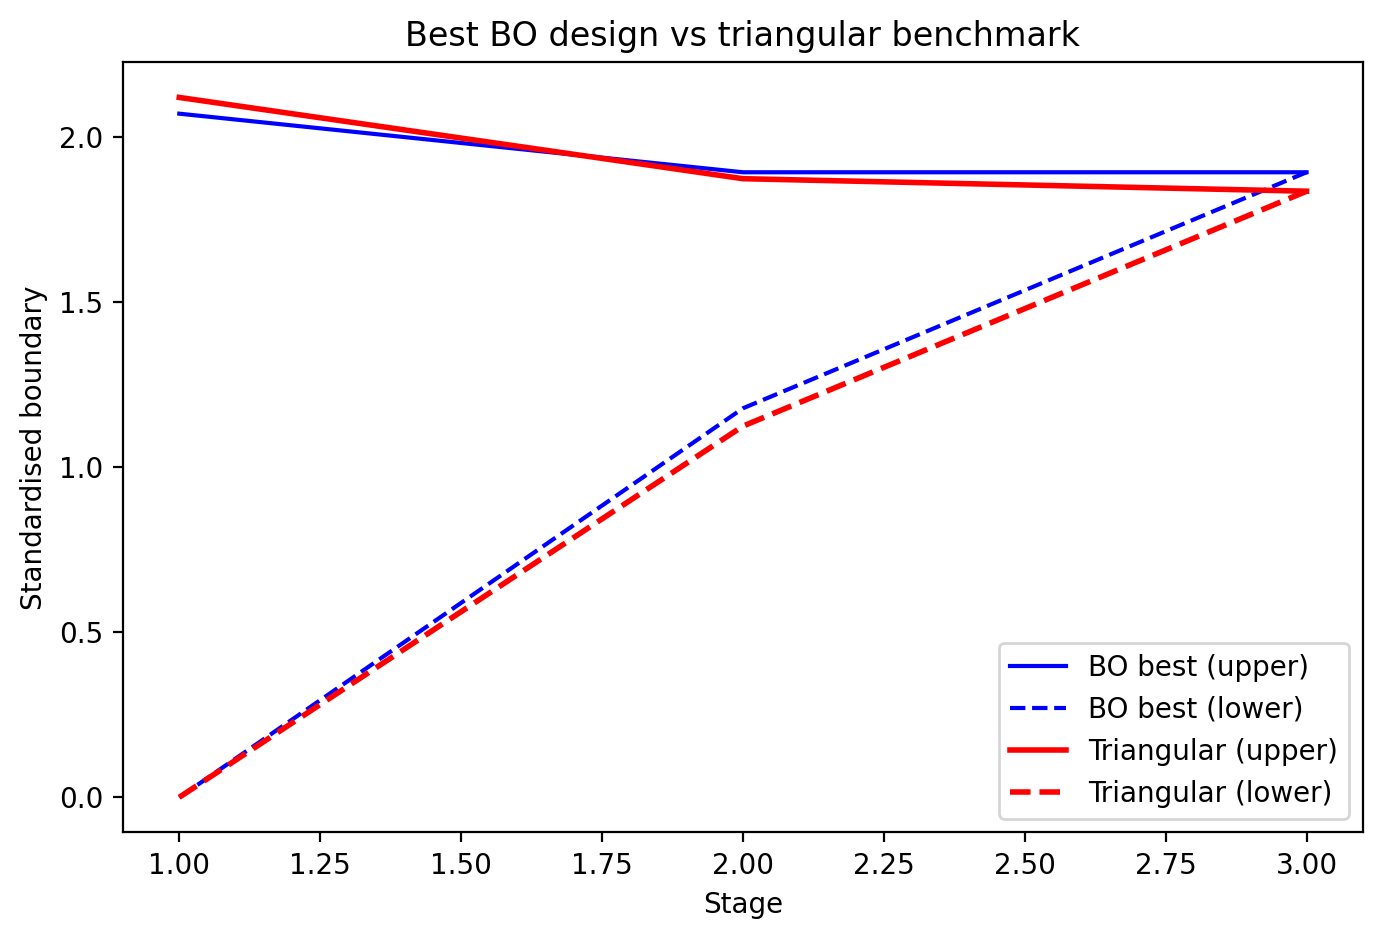

In [ ]:
_fig, _ax = plt.subplots(figsize=(8, 5))

_ax.plot([1, 2, 3], best_upper, color="blue", label="BO best (upper)")
_ax.plot([1, 2, 3], np.concatenate((best_lower[:2], [best_upper[2]])),
         color="blue", linestyle="--", label="BO best (lower)")
_ax.plot([1, 2, 3], [2.1196, 1.8735, 1.8356], color="red",
         linewidth=2, label="Triangular (upper)")
_ax.plot([1, 2, 3], [0.0, 1.1241, 1.8356], color="red",
         linewidth=2, linestyle="--", label="Triangular (lower)")

_ax.set_xlabel("Stage")
_ax.set_ylabel("Standardised boundary")
_ax.set_title("Best BO design vs triangular benchmark")
_ax.legend()
_fig

# Save Results

In [ ]:
_datasets = ask_tell.to_result().try_get_final_datasets()

_obj = _datasets["objective"]
_obj_df = pd.DataFrame(
    data    = _obj.query_points.numpy(),
    columns = ["c", "delta_u3", "delta_l3", "delta_u2", "delta_l2"]
)
_obj_df["obj_f"] = _obj.observations.numpy()
_obj_df.to_csv("/tf/paul/constrained_bo_v2_objective.csv", index=False)

_fail = _datasets["failure"]
_fail_df = pd.DataFrame(
    data    = _fail.query_points.numpy(),
    columns = ["c", "delta_u3", "delta_l3", "delta_u2", "delta_l2"]
)
_fail_df["feasible"] = _fail.observations.numpy().astype(int)
_fail_df.to_csv("/tf/paul/constrained_bo_v2_failure.csv", index=False)

print(f"Saved {_obj_df.shape[0]} feasible designs to constrained_bo_v2_objective.csv")
print(f"Saved {_fail_df.shape[0]} total designs to constrained_bo_v2_failure.csv")
print(f"Feasibility rate: {_fail_df['feasible'].mean():.1%}")

Saved 47 feasible designs to constrained_bo_v2_objective.csv
Saved 253 total designs to constrained_bo_v2_failure.csv
Feasibility rate: 18.6%
